Частина перша: Знайомство з Pandas.

Прочитайте дані за допомогою методу read_html з таблиці "Коефіцієнт народжуваності в регіонах України (1950—2019)" посилання
Будьте уважні, значення в отриманій вами таблиці можуть відрізнятися від значень у таблиці за посиланням(див.документацію)

In [50]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
import matplotlib.pyplot as plt

In [2]:
url = "https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8#%D0%9D%D0%B0%D1%80%D0%BE%D0%B4%D0%B6%D1%83%D0%B2%D0%B0%D0%BD%D1%96%D1%81%D1%82%D1%8C"

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "uk-UA,uk;q=0.9,en;q=0.8",
}

html = requests.get(url, headers=headers, timeout=30).text

df = pd.read_html(StringIO(html),match="Коефіцієнт народжуваності в регіонах України",thousands=".",decimal=","
)[0]

Вивести перші рядки таблиці за допомогою методу head

In [68]:
df.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,11.144,8.017391
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.900,7.600000
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.100,10.100000
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.100,7.100000
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.200,8.017391


Визначте кількість рядків та стовпців у датафреймі (атрибут shape)

In [4]:
print(df.shape)

(28, 9)


Замініть у таблиці значення "—" на значення NaN

In [5]:
column_list = ['1950','1960','1970','1990','2000','2012','2014','2029',]
df.loc[0,column_list[6]] = np.nan
df.loc[26,'2014'] = np.nan
df.loc[0,'2019'] = np.nan
df.loc[4,'2019'] = np.nan
df.loc[11,'2019'] = np.nan
df.loc[26,'2019'] = np.nan
df


,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,NaN,NaN
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,NaN
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


Визначте типи всіх стовпців за допомогою dataframe.dtypes

In [6]:
types = df.dtypes
print(types)

Регіон     object
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014       object
2019       object
dtype: object


Замініть типи нечислових колонок на числові. Підказка - це колонки, де знаходився символ "—"

In [7]:
for column in df.columns[1:]:
    if df[column].dtype != "float64":
        df[column] = pd.to_numeric(df[column], errors="coerce")
df.dtypes

Регіон     object
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014      float64
2019      float64
dtype: object

Порахуйте, яка частка пропусків міститься в кожній колонці (використовуйте методи isnull та sum)

In [8]:
df.isnull().sum() / len(df) * 100

Регіон     0.000000
1950       7.142857
1960       3.571429
1970       3.571429
1990       0.000000
2000       0.000000
2012       0.000000
2014       7.142857
2019      14.285714
dtype: float64

Видаліть з таблиці дані по всій країні, останній рядок таблиці

In [9]:
last_row = df.index[-1]
df = df.drop(last_row)
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,NaN,NaN
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,NaN
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


Замініть відсутні дані в стовпцях середніми значеннями цих стовпців (метод fillna)

In [10]:
# df = df.fillna({'1950': df['1950'].mean(),'1960': df['1960'].mean(),'1970': df['1970'].mean(),'1990': df['1990'].mean(),'2000': df['2000'].mean(),'2012': df['2012'].mean(),'2014': df['2014'].mean(),'2019': df['2019'].mean()})
# df
for column in df.columns[1:]:
    df = df.fillna({column: df[column].mean()})
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.000,20.600000,16.0,13.0,7.3,12.6,11.144,8.017391
1,Вінницька,22.400,19.200000,14.2,12.4,8.4,11.2,10.900,7.600000
2,Волинська,24.700,25.000000,17.9,15.3,11.2,14.8,14.100,10.100000
3,Дніпропетровська,20.400,20.400000,15.1,12.3,7.1,11.2,11.100,7.100000
4,Донецька,27.100,21.400000,14.0,10.9,6.1,9.8,8.200,8.017391
5,Житомирська,26.100,22.300000,15.9,12.9,8.9,12.2,12.000,7.900000
6,Закарпатська,31.400,27.300000,20.7,16.8,11.5,15.1,14.600,10.400000
7,Запорізька,21.900,19.700000,15.0,12.4,7.1,10.6,10.600,6.800000
8,Івано-Франківська,24.300,24.800000,18.2,15.5,10.3,12.4,12.200,8.800000
9,Київська,20.400,18.900000,15.6,12.3,7.3,12.2,12.100,8.000000


Отримайте список регіонів, де рівень народжуваності у 2019 році був вищим за середній по Україні

In [28]:
average = df['2019'].mean()
df[df['2019'] > average][['Регіон','2019']]


,Регіон,2019
2,Волинська,10.1
6,Закарпатська,10.4
8,Івано-Франківська,8.8
12,Львівська,8.7
14,Одеська,8.8
16,Рівненська,10.7
20,Херсонська,8.1
23,Чернівецька,9.2
25,Київ,11.0


У якому регіоні була найвища народжуваність у 2014 році?

In [49]:
# df['2014'].max()
# df.loc[df['2014'].idxmax()]
index_max = df['2014'].idxmax()
df.loc[index_max,['Регіон','2014']]


Регіон    Рівненська
2014            14.8
Name: 16, dtype: object

Побудуйте стовпчикову діаграму народжуваності по регіонах у 2019 році

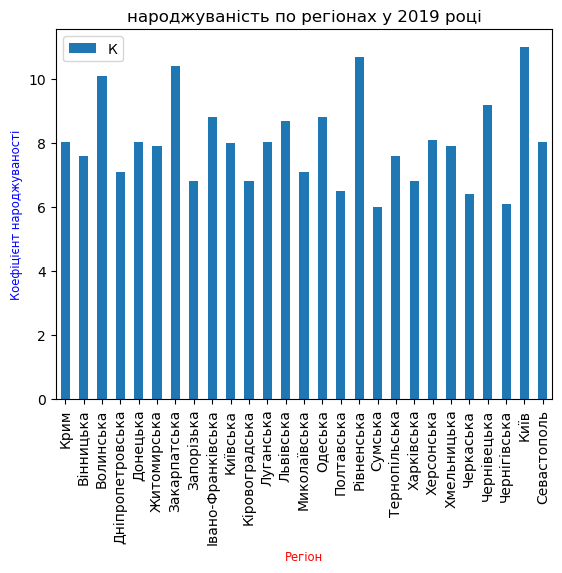

In [62]:

df.plot(x='Регіон',y='2019',kind='bar')
plt.title('народжуваність по регіонах у 2019 році')
plt.legend('Коефіцієнт народжуваності')
plt.xlabel('Регіон',fontsize='small',color="red")
plt.ylabel('Коефіцієнт народжуваності',fontsize='small',color="blue")
plt.show()